# Głębokie Uczenie w Praktyce
## Laboratorium 11
### Mateusz Horczak


#### Ćwiczenie 1. Załaduj dane uczące (fashion_mnist) i podejrzyj ich zawartość

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def load_real_samples():
    (train_x, train_y), (_, _) = keras.datasets.fashion_mnist.load_data()

    train_x = train_x[train_y.flatten() == 1]

    x = np.expand_dims(train_x, axis=-1)

    x = x.astype('float32')

    x = (x - 127.5) / 127.5
    return x

dataset = load_real_samples()
print("Dataset shape:", dataset.shape)

Dataset shape: (6000, 28, 28, 1)


#### Ćwiczenie 2. Budowa dyskryminatora

In [17]:
def build_discriminator():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,185 (1.58 MB)

 Trainable params: 413,185 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 3. Budowa generatora

In [18]:
latent_dim = 128

def build_generator(latent_size):
    model = keras.Sequential([
        keras.Input(shape=(latent_size,)),
        layers.Dense(7 * 7 * 128),
        layers.Reshape((7, 7, 128)),

        # Upsampling from 7x7 to 14x14
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),

        # Upsampling from 14x14 to 28x28
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),

        # Final layer outputting 28x28x1 image
        layers.Conv2D(1, kernel_size=7, padding="same", activation="tanh"),
    ], name="generator")
    return model

generator = build_generator(latent_dim)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 1)      │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,339,905 (5.11 MB)

 Trainable params: 1,339,905 (5.11 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 4. Budowa GAN- train_step

In [19]:
class GAN(keras.Model):
    def __init__(self, discriminator_model, generator_model, latent_size):
        super(GAN, self).__init__()
        self.discriminator = discriminator_model
        self.generator = generator_model
        self.latent_dim = latent_size

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        generated_images = self.generator(random_latent_vectors)
        combined_images = tf.concat([generated_images, real_images], axis=0)

        labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

#### Ćwiczenie 5. Trenowanie GAN

In [20]:
EPOCHS = 10
BATCH_SIZE = 64

gan = GAN(discriminator_model=discriminator, generator_model=generator, latent_size=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy()
)

history = gan.fit(
    dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
 2/94 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - d_loss: 0.6854 - g_loss: 0.6921

E0000 00:00:1780316416.245042    7658 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/discriminator_3/leaky_re_lu_24_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/discriminator_3/conv2d_19_1/BiasAdd'.


94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - d_loss: 0.4293 - g_loss: 0.8920
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - d_loss: 0.2101 - g_loss: 1.8067
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - d_loss: 0.4387 - g_loss: 2.1035
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - d_loss: 0.3525 - g_loss: 2.3603
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - d_loss: 0.4518 - g_loss: 2.0876
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - d_loss: 0.5565 - g_loss: 1.4373
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - d_loss: 0.5740 - g_loss: 1.2711
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - d_loss: 0.5775 - g_loss: 1.2357
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - d_loss: 0.6368 - g_loss: 1.2056
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - d_loss: 0.5883 - g_loss: 1.0211


#### Ćwiczenie 6. Generowanie i wyświetlanie obrazów po wytrenowaniu GAN

X.shape: (100, 28, 28, 1)


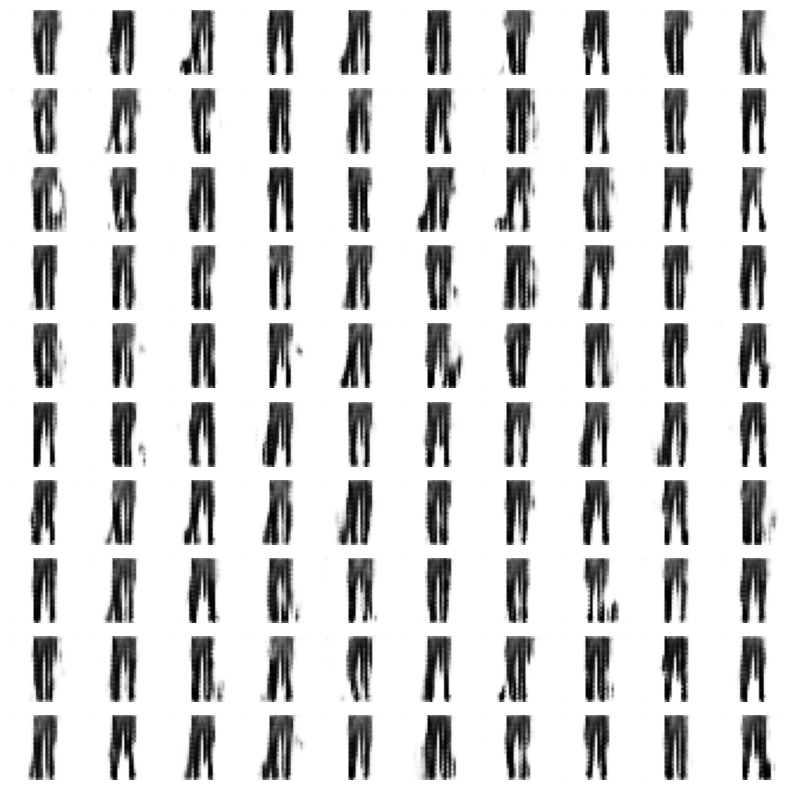

In [21]:
def generate_and_show_images(gen_model, latent_size, num_images=100):
    random_vectors = tf.random.normal(shape=(num_images, latent_size))
    generated = gen_model(random_vectors)

    generated = (generated * 127.5) + 127.5
    generated = generated.numpy()

    print(f"X.shape: {generated.shape}")

    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(10, 10, i + 1)
        plt.axis('off')
        plt.imshow(generated[i, :, :, 0], cmap='gray_r')
    plt.show()

generate_and_show_images(generator, latent_dim)

#### Ćwiczenie 7. Wizualizuj straty dyskryminatora i GAN na wykresie

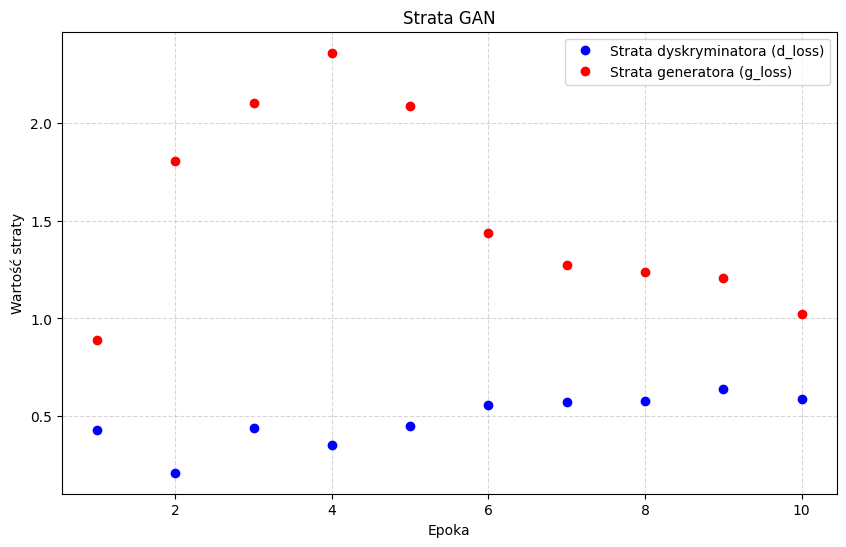

In [22]:
def plot_training_loss(training_history):
    d_loss = training_history.history['d_loss']
    g_loss = training_history.history['g_loss']
    epochs_range = range(1, len(d_loss) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(epochs_range, d_loss, 'bo', label='Strata dyskryminatora (d_loss)')
    plt.plot(epochs_range, g_loss, 'ro', label='Strata generatora (g_loss)')

    plt.title('Strata GAN')
    plt.xlabel('Epoka')
    plt.ylabel('Wartość straty')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_training_loss(history)

#### Ćwiczenie 8. Przystosuj GAN do uczenia z innym parametrami

In [23]:
def build_experimental_discriminator(conv_filters=128, dropout_rate=0.2):
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(conv_filters, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(conv_filters, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(conv_filters, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid"),
    ], name="exp_discriminator")
    return model

def build_experimental_generator(latent_size=128, conv_filters=128, use_batch_norm=True):
    model_layers = [
        keras.Input(shape=(latent_size,)),
        layers.Dense(7 * 7 * conv_filters),
        layers.Reshape((7, 7, conv_filters)),

        # 7x7 to 14x14
        layers.Conv2DTranspose(conv_filters, kernel_size=4, strides=2, padding="same"),
    ]

    if use_batch_norm:
        model_layers.append(layers.BatchNormalization())

    model_layers.append(layers.LeakyReLU(alpha=0.2))

    # 14x14 to 28x28
    model_layers.append(
        layers.Conv2DTranspose(conv_filters, kernel_size=4, strides=2, padding="same")
    )

    if use_batch_norm:
        model_layers.append(layers.BatchNormalization())

    model_layers.append(layers.LeakyReLU(alpha=0.2))
    model_layers.append(
        layers.Conv2D(1, kernel_size=7, padding="same", activation="tanh")
    )

    model = keras.Sequential(model_layers, name="exp_generator")
    return model

#### Ćwiczenie 8 - Eksperyment 1: Zmniejszony wektor ukryty (latent_dim = 64)

Epoch 1/10
 2/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - d_loss: 0.6861 - g_loss: 0.6929

E0000 00:00:1780316488.985828    7658 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/exp_discriminator_1/leaky_re_lu_29_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/exp_discriminator_1/conv2d_23_1/BiasAdd'.


94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - d_loss: 0.4169 - g_loss: 0.8757
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - d_loss: 0.2083 - g_loss: 1.9069
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - d_loss: 0.3596 - g_loss: 2.3842
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - d_loss: 0.3999 - g_loss: 2.0993
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - d_loss: 0.3936 - g_loss: 2.0974
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - d_loss: 0.6112 - g_loss: 1.1954
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - d_loss: 0.5771 - g_loss: 1.4270
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - d_loss: 0.5457 - g_loss: 1.3577
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - d_loss: 0.6108 - g_loss: 1.2242
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - d_loss: 0.5808 - g_loss: 1.0984


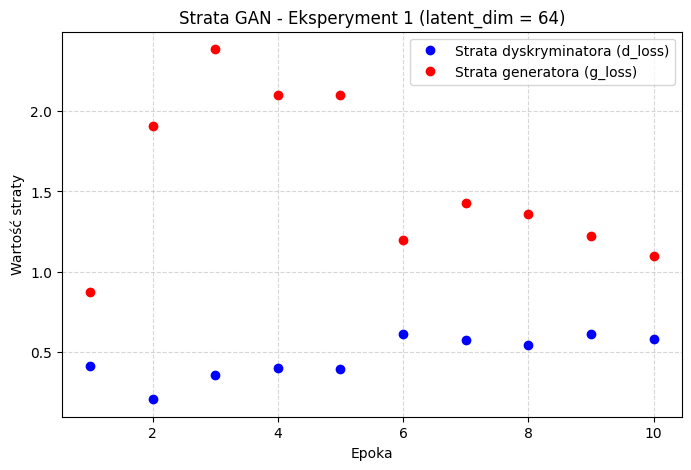

In [24]:
dim_exp1 = 64
epochs_exp = 10
batch_exp = 64

disc_exp1 = build_experimental_discriminator(conv_filters=128, dropout_rate=0.2)
gen_exp1 = build_experimental_generator(latent_size=dim_exp1, conv_filters=128, use_batch_norm=True)

gan_exp1 = GAN(discriminator_model=disc_exp1, generator_model=gen_exp1, latent_size=dim_exp1)
gan_exp1.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

history_exp1 = gan_exp1.fit(dataset, epochs=epochs_exp, batch_size=batch_exp)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_exp + 1), history_exp1.history["d_loss"], 'bo', label="Strata dyskryminatora (d_loss)")
plt.plot(range(1, epochs_exp + 1), history_exp1.history["g_loss"], 'ro', label="Strata generatora (g_loss)")
plt.title("Strata GAN - Eksperyment 1 (latent_dim = 64)")
plt.xlabel("Epoka")
plt.ylabel("Wartość straty")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Ćwiczenie 8 - Eksperyment 2: Większy learning rate (0.0002)

Epoch 1/10
 2/94 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - d_loss: 0.6728 - g_loss: 0.6892

E0000 00:00:1780316568.635222    7658 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/exp_discriminator_3/leaky_re_lu_34_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/exp_discriminator_3/conv2d_27_1/BiasAdd'.


94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - d_loss: 0.3522 - g_loss: 1.2283
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - d_loss: 0.2865 - g_loss: 2.9290
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - d_loss: 0.3559 - g_loss: 2.9981
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - d_loss: 0.4001 - g_loss: 2.2319
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - d_loss: 0.5442 - g_loss: 1.6545
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - d_loss: 0.5092 - g_loss: 1.8131
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - d_loss: 0.5717 - g_loss: 1.4248
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - d_loss: 0.5871 - g_loss: 1.1787
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - d_loss: 0.5043 - g_loss: 1.5305
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - d_loss: 0.4759 - g_loss: 1.8942


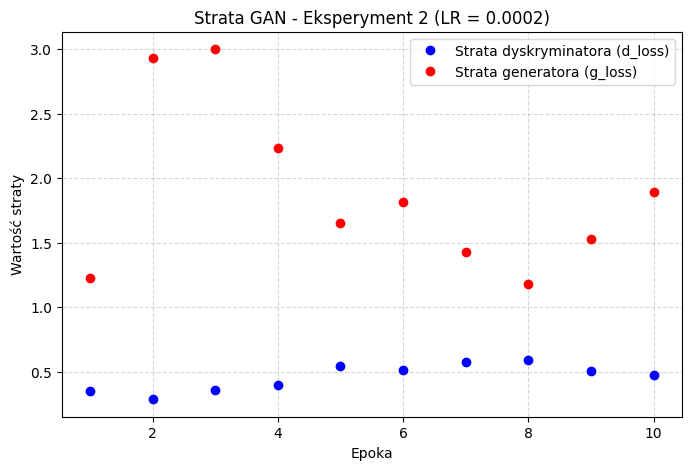

In [25]:
dim_exp2 = 128

disc_exp2 = build_experimental_discriminator(conv_filters=128, dropout_rate=0.2)
gen_exp2 = build_experimental_generator(latent_size=dim_exp2, conv_filters=128, use_batch_norm=True)

gan_exp2 = GAN(discriminator_model=disc_exp2, generator_model=gen_exp2, latent_size=dim_exp2)
gan_exp2.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002), # Zmieniony LR
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002), # Zmieniony LR
    loss_fn=keras.losses.BinaryCrossentropy(),
)

history_exp2 = gan_exp2.fit(dataset, epochs=epochs_exp, batch_size=batch_exp)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_exp + 1), history_exp2.history["d_loss"], 'bo', label="Strata dyskryminatora (d_loss)")
plt.plot(range(1, epochs_exp + 1), history_exp2.history["g_loss"], 'ro', label="Strata generatora (g_loss)")
plt.title("Strata GAN - Eksperyment 2 (LR = 0.0002)")
plt.xlabel("Epoka")
plt.ylabel("Wartość straty")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Ćwiczenie 8 - Eksperyment 3: Mniej filtrów w warstwach (conv_filters = 64)

Epoch 1/10
 5/94 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - d_loss: 0.6604 - g_loss: 0.6900

E0000 00:00:1780316647.209560    7658 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/exp_discriminator_1/leaky_re_lu_37_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/exp_discriminator_1/conv2d_29_1/BiasAdd'.


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - d_loss: 0.4485 - g_loss: 0.8196
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - d_loss: 0.2846 - g_loss: 1.1251
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - d_loss: 0.2643 - g_loss: 1.9474
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - d_loss: 0.5511 - g_loss: 1.3905
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - d_loss: 0.5340 - g_loss: 1.2356
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - d_loss: 0.5741 - g_loss: 1.1753
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - d_loss: 0.6566 - g_loss: 0.9348
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - d_loss: 0.6173 - g_loss: 0.9424
Epoch 9/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - d_loss: 0.6381 - g_loss: 0.9558
Epoch 10/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - d_loss: 0.6623 - g_loss: 0.8848


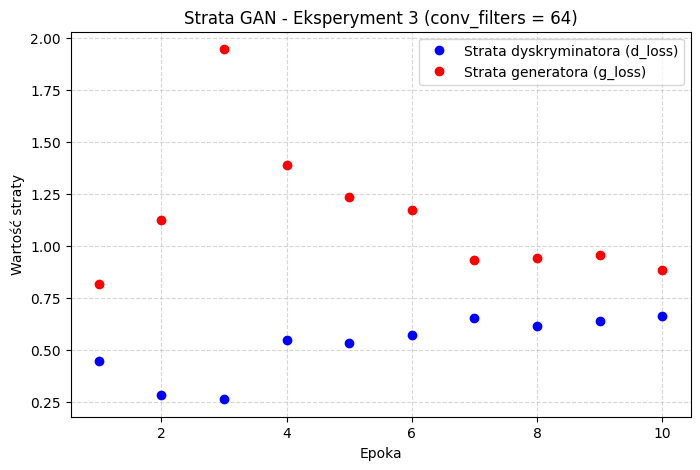

In [26]:
dim_exp3 = 128

disc_exp3 = build_experimental_discriminator(conv_filters=64, dropout_rate=0.2) # Mniej filtrów
gen_exp3 = build_experimental_generator(latent_size=dim_exp3, conv_filters=64, use_batch_norm=True) # Mniej filtrów

gan_exp3 = GAN(discriminator_model=disc_exp3, generator_model=gen_exp3, latent_size=dim_exp3)
gan_exp3.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

history_exp3 = gan_exp3.fit(dataset, epochs=epochs_exp, batch_size=batch_exp)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_exp + 1), history_exp3.history["d_loss"], 'bo', label="Strata dyskryminatora (d_loss)")
plt.plot(range(1, epochs_exp + 1), history_exp3.history["g_loss"], 'ro', label="Strata generatora (g_loss)")
plt.title("Strata GAN - Eksperyment 3 (conv_filters = 64)")
plt.xlabel("Epoka")
plt.ylabel("Wartość straty")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Ćwiczenie 8 - Podsumowanie: Porównanie strat generatorów (g_loss)

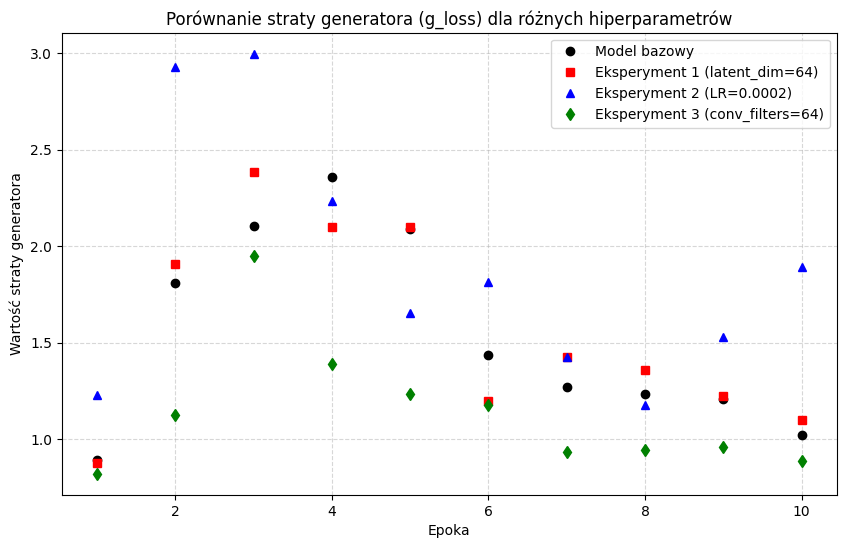

In [27]:
epochs_range = range(1, epochs_exp + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, history.history["g_loss"][:epochs_exp], 'ko', label="Model bazowy")
plt.plot(epochs_range, history_exp1.history["g_loss"], 'rs', label="Eksperyment 1 (latent_dim=64)")
plt.plot(epochs_range, history_exp2.history["g_loss"], 'b^', label="Eksperyment 2 (LR=0.0002)")
plt.plot(epochs_range, history_exp3.history["g_loss"], 'gd', label="Eksperyment 3 (conv_filters=64)")

plt.title("Porównanie straty generatora (g_loss) dla różnych hiperparametrów")
plt.xlabel("Epoka")
plt.ylabel("Wartość straty generatora")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()